# Domain-Specific Embeddings for Financial RAG

**Docker image**: `ml4t-gpu`

**Chapter 22: RAG for Financial Research** (Section 22.4)

Two open-weight embedding models index the same 10-K passages and answer the
same fifteen queries, and the notebook asks which retrieves better. The
interesting part is not the answer. It is that the evaluation this notebook
can run without human annotators is too weak to give one, and the notebook
measures how weak rather than asserting a ranking on top of it.

The models are BGE-large and MiniLM, both pinned to a revision and run
locally. OpenAI and Voyage AI candidates are wired up and stay off unless
both `USE_LOCAL_MODELS_ONLY` is cleared and the corresponding key is set, so
the shipped run costs nothing and contacts nothing.

**Learning objectives**

After working through this notebook you will be able to:

- Build a retrieval evaluation from an unlabelled corpus, and say which part
  of it is a measurement and which part is an assumption.
- Read a Precision@k or MRR difference back into the number of documents it
  represents, and decide whether that number supports a ranking.
- Say what a lexical-overlap relevance proxy can and cannot detect, from the
  size of the candidate pool its labels are drawn out of.
- Run two pinned open-weight embedding models over the same corpus and query
  set, on a GPU, with no managed API in the loop.

**Prerequisites**

- The SP100 10-K corpus, read through `data.load_sec_filings`. Note what
  [`01_sec_filing_pipeline`](01_sec_filing_pipeline.ipynb) establishes about
  it: for most of the corpus the stored text is a window taken around the
  filing's first mention of suppliers, not the annual report. The passages
  below inherit that, and so does every score in this notebook.
- `sentence-transformers`, and a CUDA GPU. `REQUIRE_GPU` refuses a CPU run
  rather than producing numbers an hour later that nobody compares against.
- Optional: `OPENAI_API_KEY`, `VOYAGE_API_KEY`.

**Book reference**: Section 22.4, which discusses domain embeddings, the
FinMTEB benchmark, and Matryoshka embedding compression.

## Setup

The query and document budgets are fixed here so that a later change in the
ranking is a change in the embedding and not a change in the workload.

In [1]:
"""Domain-Specific Embeddings - Compare embedding models for financial retrieval."""

import hashlib
import json
import os
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch

# Visualization
from IPython.display import Markdown, display
from plotly.subplots import make_subplots

# ML4T configuration
from data import load_sec_filings
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
MAX_QUERIES = 0  # 0 means every query in FINANCIAL_QUERIES below
MAX_DOCUMENTS = 0  # 0 means DEFAULT_DOCUMENT_CAP
DEFAULT_DOCUMENT_CAP = 200  # passages to keep; the corpus is smaller, so it does not bind
USE_LOCAL_MODELS_ONLY = True
REQUIRE_GPU = True
SEED = 42
MODEL_REVISIONS = {
    "BAAI/bge-large-en-v1.5": "d4aa6901d3a41ba39fb536a557fa166f842b0e09",
    "sentence-transformers/all-MiniLM-L6-v2": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41",
}
MODEL_QUERY_PREFIXES = {
    "BAAI/bge-large-en-v1.5": "Represent this sentence for searching relevant passages: ",
    "sentence-transformers/all-MiniLM-L6-v2": "",
}
EXPECTED_INPUT_SHA256 = "d0d8021167f79c49e0a5a4420294c9ff2f3534e4c9eb10f580c3e3901fb4945b"

In [3]:
set_global_seeds(SEED)

if REQUIRE_GPU and not torch.cuda.is_available():
    raise RuntimeError("This production benchmark requires a CUDA-capable GPU.")
EMBEDDING_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Embedding device: {EMBEDDING_DEVICE}")

Embedding device: cuda


`MAX_QUERIES` and `MAX_DOCUMENTS` are caps, not counts: zero means the
notebook uses everything the corpus and the query list produce, subject to
`DEFAULT_DOCUMENT_CAP`. The actual counts are printed where each is built,
because a cap that never binds says nothing about what ran.

In [4]:
DOCUMENT_CAP = MAX_DOCUMENTS if MAX_DOCUMENTS > 0 else DEFAULT_DOCUMENT_CAP
print(f"Query cap:    {MAX_QUERIES if MAX_QUERIES > 0 else 'none'}")
print(f"Document cap: {DOCUMENT_CAP}")

Query cap:    none
Document cap: 200


## 1. The passages being retrieved over

Eight symbols, their most recent 10-K each, cut into passages of two
sentences. The text is real filing prose rather than synthetic snippets,
which is what makes the vocabulary worth embedding - and per
[`01_sec_filing_pipeline`](01_sec_filing_pipeline.ipynb), most of it is the
part of each filing that discusses suppliers. A query about supply chains
has more to match here than a query about, say, revenue recognition, and the
scores below carry that.

The corpus identity is checked against a pinned hash before anything is
embedded, so a corpus that has been regenerated stops the run instead of
quietly changing every number in it.

In [5]:
def sha256_file(path: Path) -> str:
    """Return the SHA-256 digest of a local file."""
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

In [6]:
input_path = (
    Path(os.getenv("ML4T_DATA_PATH", "data"))
    / "equities/fundamentals/10k/sp100/reference/all_10k_filings.parquet"
)
INPUT_SHA256 = sha256_file(input_path)
if INPUT_SHA256 != EXPECTED_INPUT_SHA256:
    raise RuntimeError(f"Unexpected 10-K corpus identity: {INPUT_SHA256}")
print(f"Input SHA-256: {INPUT_SHA256}")

Input SHA-256: d0d8021167f79c49e0a5a4420294c9ff2f3534e4c9eb10f580c3e3901fb4945b


In [7]:
SAMPLE_SYMBOLS = ["AAPL", "MSFT", "AMZN", "JPM", "JNJ", "XOM", "BA", "ADBE"]
filings_df = (
    load_sec_filings(form_type="10-K", universe="sp100", symbols=SAMPLE_SYMBOLS)
    .sort(["filing_date", "symbol"], descending=[True, False])
    .unique(subset=["symbol"], keep="first")
    .sort("symbol")
)

chunks = []
for row in filings_df.iter_rows(named=True):
    symbol = row["symbol"]
    text = row["text"]
    if not text or len(text) < 200:
        continue
    # Two sentences per passage, on the "*. *" boundary, skipping fragments.
    sentences = [s.strip() for s in text.replace("\n", " ").split(". ") if len(s.strip()) > 40]
    for j in range(0, len(sentences) - 1, 2):
        chunk = ". ".join(sentences[j : j + 2]) + "."
        if 80 < len(chunk) < 600:
            chunks.append(f"[{symbol}] {chunk}")

# Sample down to the cap only if the chunking produced more than it. Sampling
# when it did not would permute the corpus and change nothing else, which is a
# step that looks like a decision and is not one.
if len(chunks) > DOCUMENT_CAP:
    rng = np.random.default_rng(SEED)
    keep = sorted(rng.choice(len(chunks), size=DOCUMENT_CAP, replace=False))
    FINANCIAL_DOCUMENTS = [chunks[i] for i in keep]
else:
    FINANCIAL_DOCUMENTS = list(chunks)

FINANCIAL_DOCUMENT_IDS = [
    hashlib.sha256(document.encode()).hexdigest() for document in FINANCIAL_DOCUMENTS
]
CORPUS_SHA256 = hashlib.sha256("\n".join(FINANCIAL_DOCUMENT_IDS).encode()).hexdigest()

print(f"Chunked {len(chunks)} passages from {len(SAMPLE_SYMBOLS)} symbols")
print(f"Kept {len(FINANCIAL_DOCUMENTS)} against a cap of {DOCUMENT_CAP}")
print(f"Passages per symbol: {dict(sorted(Counter(d[1 : d.index(']')] for d in chunks).items()))}")
print(f"Selected corpus SHA-256: {CORPUS_SHA256}")
assert FINANCIAL_DOCUMENTS, "The filing slice did not produce any retrieval documents."
assert len(set(FINANCIAL_DOCUMENT_IDS)) == len(FINANCIAL_DOCUMENT_IDS)

Chunked 191 passages from 8 symbols
Kept 191 against a cap of 200
Passages per symbol: {'AAPL': 31, 'ADBE': 14, 'AMZN': 28, 'BA': 30, 'JNJ': 10, 'JPM': 22, 'MSFT': 33, 'XOM': 23}
Selected corpus SHA-256: 242a2e1009e1c6350700290e3acc7ffb365e34820ded19453348bfd1b164866c


Every model below sees exactly this list, in this order, so a difference in
score is a difference in the embedding.

In [8]:
FINANCIAL_QUERIES = [
    # Product, IP and compliance language.
    ("What competitive threats does the company face from low-cost competitors?", "technical"),
    ("How does the company protect its intellectual property?", "technical"),
    ("What are the company's key product development strategies?", "technical"),
    ("Describe the company's approach to hardware and software integration", "technical"),
    ("What regulatory compliance requirements affect operations?", "technical"),
    # Risk-factor language. The first of these asks about the topic the corpus
    # was cut on, which is worth remembering when reading the risk slice.
    ("What are the main risks to the company's supply chain?", "risk"),
    ("How does the company manage concentration risk in its customer base?", "risk"),
    ("What cybersecurity risks does the company disclose?", "risk"),
    ("How do currency fluctuations affect international operations?", "risk"),
    ("What legal proceedings or litigation risks exist?", "risk"),
    # Broad business language, with no term of art to key on.
    ("How large is the company's workforce?", "general"),
    ("What markets does the company operate in?", "general"),
    ("How does the company distribute its products?", "general"),
    ("What is the company's competitive position?", "general"),
    ("What recent acquisitions or divestitures has the company made?", "general"),
]

if MAX_QUERIES > 0:
    FINANCIAL_QUERIES = FINANCIAL_QUERIES[:MAX_QUERIES]

N_QUERIES = len(FINANCIAL_QUERIES)

queries_df = pl.DataFrame(
    {"query": [q[0] for q in FINANCIAL_QUERIES], "query_type": [q[1] for q in FINANCIAL_QUERIES]}
)
QUERY_SHA256 = hashlib.sha256(json.dumps(FINANCIAL_QUERIES, sort_keys=True).encode()).hexdigest()

print(f"\nQuery set: {N_QUERIES} queries")
print(f"Query-set SHA-256: {QUERY_SHA256}")
queries_df.group_by("query_type").len()


Query set: 15 queries
Query-set SHA-256: 01f14c7320311b0cd03ba5d48de46cdec20b4c4c2eca6d00a932bbb3a8f627f2


query_type,len
str,u32
"""general""",5
"""risk""",5
"""technical""",5


Five queries in each of three registers. Five is small, and the by-slice
numbers later have to be read as five queries rather than as a property of
the register - a point section 5 returns to with the counts.

## 2. Embedding Model Implementations

We compare multiple embedding approaches:

| Model Family | Example Candidate | Notes |
|--------------|-------------------|-------|
| General API  | text-embedding-*  | strong baseline, managed service |
| Finance API  | finance-adapted API model | domain specialization, managed service |
| Open-weight  | BGE / MiniLM / E5-style | local control and cost flexibility |

### OpenAI Embeddings

Managed API service providing high-quality general-purpose embeddings.
Requires `OPENAI_API_KEY` environment variable and provides the generic
baseline for interpreting whether finance specialization adds value.

In [9]:
def get_openai_embeddings(texts: list, model: str = "text-embedding-3-small") -> np.ndarray | None:
    """
    Get embeddings from OpenAI API.

    Returns None if API unavailable.
    """
    import os

    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        print(f"  OpenAI API key not set - skipping {model}")
        return None

    try:
        from openai import OpenAI

        client = OpenAI()

        response = client.embeddings.create(input=texts, model=model)

        embeddings = np.array([item.embedding for item in response.data])
        print(f"  {model}: {embeddings.shape}")
        return embeddings

    except Exception as e:
        print(f"  {model} error: {e}")
        return None

### Voyage Finance Embeddings

Domain-specific embedding candidate for technical queries involving WACC,
EBITDA, basis points, and other financial terminology.

It stays off in the shipped run. Where a key is present, it is the one
candidate here that was trained on financial text rather than adapted to it.

In [10]:
def get_voyage_embeddings(texts: list, model: str = "voyage-finance-2") -> np.ndarray | None:
    """
    Get embeddings from Voyage AI API.

    voyage-finance-2 is specifically trained for financial text.
    """
    import os

    api_key = os.getenv("VOYAGE_API_KEY")
    if not api_key:
        print(f"  Voyage API key not set - skipping {model}")
        return None

    try:
        import voyageai

        client = voyageai.Client()
        result = client.embed(texts, model=model)

        embeddings = np.array(result.embeddings)
        print(f"  {model}: {embeddings.shape}")
        return embeddings

    except Exception as e:
        print(f"  {model} error: {e}")
        return None

### Local Open-Weight Embeddings

BGE-large and MiniLM are public, pinned open-weight controls. FinE5 is not a
local candidate because its official repository publishes a model card but no
runtime files. It is available through a separate managed service, so readers
should not expect `from_pretrained()` to download it from Hugging Face.

In [11]:
def get_sentence_transformer_embeddings(
    texts: list[str], model_name: str, input_type: str
) -> np.ndarray:
    """
    Get embeddings from sentence-transformers (local, free).

    Local candidates are mandatory, so any model-load or encoding failure raises.
    """
    warnings.filterwarnings(
        "ignore",
        message="'return' in a 'finally' block",
        category=SyntaxWarning,
    )
    from sentence_transformers import SentenceTransformer

    model = SentenceTransformer(
        model_name,
        revision=MODEL_REVISIONS[model_name],
        device=EMBEDDING_DEVICE,
        local_files_only=True,
    )
    model_device = next(model.parameters()).device
    if REQUIRE_GPU and model_device.type != "cuda":
        raise RuntimeError(f"{model_name} parameters are on {model_device}, not CUDA.")

    prefix = MODEL_QUERY_PREFIXES[model_name] if input_type == "query" else ""
    model_inputs = [f"{prefix}{text}" for text in texts]
    embeddings = model.encode(model_inputs, show_progress_bar=False, normalize_embeddings=True)

    print(f"  {model_name} ({input_type}): {embeddings.shape}; parameters={model_device}")
    return embeddings

## 3. Generate Embeddings for Comparison

Documents and queries go through each model in turn. BGE-large takes a query
prefix and MiniLM does not, which is a property of how each was trained and
is applied here rather than left to the reader.

In [12]:
print("=== Generating Document Embeddings ===\n")

document_embeddings = {}
query_embeddings = {}

# Default to two locally-runnable open-source models so the comparison
# always exercises a real retrieval workload. API-backed candidates are
# added only when the corresponding API keys are present.
MODELS: list = [
    (
        "bge-large",
        lambda texts, input_type: get_sentence_transformer_embeddings(
            texts, "BAAI/bge-large-en-v1.5", input_type
        ),
    ),
    (
        "minilm",
        lambda texts, input_type: get_sentence_transformer_embeddings(
            texts, "sentence-transformers/all-MiniLM-L6-v2", input_type
        ),
    ),
]

=== Generating Document Embeddings ===



In [13]:
if not USE_LOCAL_MODELS_ONLY:
    if os.getenv("OPENAI_API_KEY"):
        MODELS.append(
            (
                "openai-small",
                lambda texts, _input_type: get_openai_embeddings(texts, "text-embedding-3-small"),
            )
        )
        MODELS.append(
            (
                "openai-large",
                lambda texts, _input_type: get_openai_embeddings(texts, "text-embedding-3-large"),
            )
        )
    if os.getenv("VOYAGE_API_KEY"):
        MODELS.append(
            (
                "voyage-finance",
                lambda texts, _input_type: get_voyage_embeddings(texts, "voyage-finance-2"),
            )
        )

In [14]:
print("Models in run:", [m[0] for m in MODELS])

Models in run: ['bge-large', 'minilm']


### Embed the corpus and query set

Every candidate sees the same documents and queries, so a difference in score
is a difference in the embedding. The print above names the candidates that
survived the environment checks, which is what the scores below are of.

In [15]:
for model_name, embed_fn in MODELS:
    print(f"Embedding with {model_name}...")

    # Embed documents
    doc_emb = embed_fn(FINANCIAL_DOCUMENTS, "document")
    if doc_emb is not None:
        document_embeddings[model_name] = doc_emb

    # Embed queries
    query_texts = [q[0] for q in FINANCIAL_QUERIES]
    query_emb = embed_fn(query_texts, "query")
    if query_emb is not None:
        query_embeddings[model_name] = query_emb

print(f"\nModels with embeddings: {list(document_embeddings.keys())}")
required_local_models = {"bge-large", "minilm"}
missing_local_models = required_local_models - document_embeddings.keys()
if missing_local_models:
    raise RuntimeError(f"Missing required local embedding results: {missing_local_models}")

Embedding with bge-large...


  BAAI/bge-large-en-v1.5 (document): (191, 1024); parameters=cuda:0


  BAAI/bge-large-en-v1.5 (query): (15, 1024); parameters=cuda:0
Embedding with minilm...


  sentence-transformers/all-MiniLM-L6-v2 (document): (191, 384); parameters=cuda:0


  sentence-transformers/all-MiniLM-L6-v2 (query): (15, 384); parameters=cuda:0

Models with embeddings: ['bge-large', 'minilm']


A missing key narrows the candidate set and changes nothing else. The two
local models are required, and their absence raises rather than shrinking the
comparison to one model without saying so.

## 4. Scoring the retrieval, and what the score is against

Retrieval quality is a comparison against a set of documents someone decided
were the right answers. Nobody has annotated this corpus, so this notebook
builds that set out of term overlap and then measures agreement with it:

- **Cosine similarity** ranks documents against a query.
- **Precision@k** counts how many of the top k are in the proxy set.
- **Mean reciprocal rank** records how early the first one appears.

The proxy is the weak part, and the section that builds it measures how
weak before any model is scored against it. Read every
number after this point as agreement with a term-overlap rule, not as
retrieval quality.

### Cosine similarity

One matrix of query-document similarities per model. Both models already
return unit vectors, so the normalization below is a guard rather than a
transformation.

In [16]:
def cosine_similarity(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Compute cosine similarity matrix between query and document embeddings."""
    # Normalize
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True)

    # Compute similarity
    return np.dot(a_norm, b_norm.T)

### The proxy labels, and the pool they are drawn from

Drop the stopwords from a query, count how many of the remaining terms appear
in each document, and call the three highest-scoring documents relevant.

Two properties of that rule decide how to read everything below. The first is
that it favours literal term coverage, so it rewards a retriever for lexical
matching and cannot reward one for understanding a paraphrase - which is the
thing an embedding is supposed to add.

The second is that "the three highest" is only a ranking where the scores
differ. Overlap is a small integer, so the third-placed document often shares
its score with many others and the tie-break decides the label by a hash of
the document text. The cell below measures that directly: for each query it
records the overlap score the third label was taken at, and how many
documents in the corpus carry that same score.

In [17]:
STOPWORDS = {
    "what",
    "is",
    "the",
    "how",
    "are",
    "does",
    "explain",
    "a",
    "an",
    "and",
    "or",
    "of",
    "to",
    "in",
    "for",
    "has",
    "have",
    "been",
}


def get_relevance_labels(query: str, documents: list[str], document_ids: list[str]) -> list[bool]:
    """Label the three documents with the highest query-term overlap as relevant.

    Ties break on the document id, so the label set does not depend on corpus
    order. Documents with no overlap are never labelled, so a query matching
    fewer than three documents gets fewer than three positives.
    """
    query_terms = [w.lower().strip("?.,") for w in query.split() if w.lower() not in STOPWORDS]

    if len(documents) != len(document_ids):
        raise ValueError("documents and document_ids must have the same length")
    overlap = [sum(1 for term in query_terms if term in doc.lower()) for doc in documents]
    positive = [index for index, score in enumerate(overlap) if score > 0]
    ranked = sorted(positive, key=lambda index: (-overlap[index], document_ids[index]))[:3]
    return [index in ranked for index in range(len(documents))]

In [18]:
for query, _query_type in FINANCIAL_QUERIES:
    if not any(get_relevance_labels(query, FINANCIAL_DOCUMENTS, FINANCIAL_DOCUMENT_IDS)):
        raise ValueError(f"No lexical-proxy positive document for query: {query}")

In [19]:
def overlap_scores(query: str, documents: list[str]) -> list[int]:
    """Query-term overlap count for every document, the quantity the labels rank on."""
    terms = [w.lower().strip("?.,") for w in query.split() if w.lower() not in STOPWORDS]
    return [sum(1 for term in terms if term in doc.lower()) for doc in documents]


def cutoff_and_ties(
    query: str, documents: list[str], document_ids: list[str]
) -> tuple[int, int, int]:
    """Overlap score of the last label, how many documents share it, how many of those got a label."""
    scores = overlap_scores(query, documents)
    labelled = [
        i for i, keep in enumerate(get_relevance_labels(query, documents, document_ids)) if keep
    ]
    cutoff = min(scores[i] for i in labelled)
    tied = sum(1 for score in scores if score == cutoff)
    labelled_at_cutoff = sum(1 for i in labelled if scores[i] == cutoff)
    return cutoff, tied, labelled_at_cutoff


cutoffs = [
    cutoff_and_ties(q, FINANCIAL_DOCUMENTS, FINANCIAL_DOCUMENT_IDS) for q, _ in FINANCIAL_QUERIES
]
proxy_ties = (
    pl.DataFrame(
        {
            "query_type": [t for _, t in FINANCIAL_QUERIES],
            "query": [q for q, _ in FINANCIAL_QUERIES],
            "cutoff_overlap": [c for c, _, _ in cutoffs],
            "tied_at_cutoff": [t for _, t, _ in cutoffs],
            "labels_from_tie": [n for _, _, n in cutoffs],
        }
    )
    .with_columns(
        (pl.col("tied_at_cutoff") - pl.col("labels_from_tie")).alias("tied_but_unlabelled")
    )
    .sort("tied_but_unlabelled", descending=True)
)
proxy_ties.with_columns(pl.col("query").str.slice(0, 44))

query_type,query,cutoff_overlap,tied_at_cutoff,labels_from_tie,tied_but_unlabelled
str,str,i64,i64,i64,i64
"""general""","""What recent acquisitions or di…",1,41,2,39
"""risk""","""What legal proceedings or liti…",1,36,3,33
"""general""","""What is the company's competit…",1,19,1,18
"""general""","""How large is the company's wor…",1,19,3,16
"""risk""","""What cybersecurity risks does …",2,14,3,11
…,…,…,…,…,…
"""technical""","""What competitive threats does …",3,3,2,1
"""technical""","""How does the company protect i…",4,2,1,1
"""risk""","""What are the main risks to the…",2,4,3,1


`cutoff_overlap` is the overlap score of the lowest-scoring labelled
document. `tied_at_cutoff` counts every document in the corpus at that score,
`labels_from_tie` is how many of the three labels were taken from among them,
and `tied_but_unlabelled` is the remainder: documents the rule scored exactly
as highly as a label it did award, and did not award, because the tie-break
is a hash of the document text.

Those are the documents a retriever gets no credit for returning. Where the
last column runs into the tens, the label set is not a relevance judgment at
the margin - it is a coin toss the retriever has to match.

Note what this does not track: how common the query's words are. The query
overlapping the most documents in this corpus is among the least arbitrary,
because its labels sit at a score few documents reach.

### Precision@k

The share of the top k retrieved documents that carry a proxy label. Its
ceiling is not 1 for every k: with at most three labelled documents per
query, Precision@5 cannot exceed three in five however good the retrieval
is, so P@3 and P@5 are not on the same scale and a fall between them is
arithmetic rather than a decline.

In [20]:
def stable_rank_indices(similarities: np.ndarray, document_ids: list[str]) -> list[int]:
    """Rank scores descending with immutable document identity as the tie-break."""
    return sorted(
        range(len(similarities)),
        key=lambda index: (-float(similarities[index]), document_ids[index]),
    )

Apply the stable ranking rule to Precision@k.

In [21]:
def compute_precision_at_k(
    similarities: np.ndarray, relevance: list, document_ids: list[str], k: int = 3
) -> float:
    """Compute Precision@k for a single query."""
    top_k_indices = stable_rank_indices(similarities, document_ids)[:k]
    top_k_relevant = sum(relevance[i] for i in top_k_indices)
    return top_k_relevant / k

### Mean reciprocal rank

One over the rank of the first labelled document, averaged over queries. It
reaches 1 when every query puts a labelled document first, and it does not
have the k-dependent ceiling Precision@k has.

In [22]:
def compute_mrr(similarities: np.ndarray, relevance: list, document_ids: list[str]) -> float:
    """Compute Mean Reciprocal Rank for a single query."""
    ranked_indices = stable_rank_indices(similarities, document_ids)
    for rank, idx in enumerate(ranked_indices, 1):
        if relevance[idx]:
            return 1.0 / rank
    return 0.0

In [23]:
print("=== Computing Retrieval Metrics ===\n")

results = []

for model_name in document_embeddings:
    if model_name not in query_embeddings:
        continue

    doc_emb = document_embeddings[model_name]
    q_emb = query_embeddings[model_name]

    # Compute similarity matrix
    sim_matrix = cosine_similarity(q_emb, doc_emb)

    # Evaluate each query
    for i, (query, query_type) in enumerate(FINANCIAL_QUERIES):
        relevance = get_relevance_labels(query, FINANCIAL_DOCUMENTS, FINANCIAL_DOCUMENT_IDS)

        p_at_1 = compute_precision_at_k(sim_matrix[i], relevance, FINANCIAL_DOCUMENT_IDS, k=1)
        p_at_3 = compute_precision_at_k(sim_matrix[i], relevance, FINANCIAL_DOCUMENT_IDS, k=3)
        p_at_5 = compute_precision_at_k(sim_matrix[i], relevance, FINANCIAL_DOCUMENT_IDS, k=5)
        mrr = compute_mrr(sim_matrix[i], relevance, FINANCIAL_DOCUMENT_IDS)

        results.append(
            {
                "model": model_name,
                "query": query[:50] + "..." if len(query) > 50 else query,
                "query_type": query_type,
                "precision_at_1": p_at_1,
                "precision_at_3": p_at_3,
                "precision_at_5": p_at_5,
                "mrr": mrr,
                "n_relevant": sum(relevance),
            }
        )

results_df = pl.DataFrame(results)
print(f"Evaluated {len(results)} query-model combinations")

=== Computing Retrieval Metrics ===

Evaluated 30 query-model combinations


Thirty rows: two models against fifteen queries, each scored against the same
labels.

## 5. Results

Two aggregates, then the count behind them. The count is the part that
decides whether the aggregates support anything.

In [24]:
if len(results) == 0:
    raise RuntimeError(
        "No embedding model produced results. Install sentence-transformers "
        "or enable a configured managed embedding service and re-run."
    )

In [25]:
# Aggregate by model
model_summary = (
    results_df.group_by("model")
    .agg(
        pl.col("precision_at_1").mean().alias("avg_p@1"),
        pl.col("precision_at_3").mean().alias("avg_p@3"),
        pl.col("precision_at_5").mean().alias("avg_p@5"),
        pl.col("mrr").mean().alias("avg_mrr"),
    )
    .sort(["avg_mrr", "model"], descending=[True, False])
)

print("=== Model Comparison (Overall) ===\n")
model_summary

=== Model Comparison (Overall) ===



model,avg_p@1,avg_p@3,avg_p@5,avg_mrr
str,f64,f64,f64,f64
"""bge-large""",0.2,0.177778,0.133333,0.337732
"""minilm""",0.066667,0.155556,0.146667,0.261442


Read `avg_p@5` against a ceiling of three in five, not against one.

In [26]:
# Aggregate by model and query type
type_summary = (
    results_df.group_by(["model", "query_type"])
    .agg(
        pl.col("precision_at_3").mean().alias("avg_p@3"),
        pl.col("mrr").mean().alias("avg_mrr"),
    )
    .sort(["query_type", "avg_mrr", "model"], descending=[False, True, False])
)

print("\n=== Model Comparison by Query Type ===\n")
type_summary


=== Model Comparison by Query Type ===



model,query_type,avg_p@3,avg_mrr
str,str,f64,f64
"""minilm""","""general""",0.066667,0.162381
"""bge-large""","""general""",0.0,0.110696
"""bge-large""","""risk""",0.2,0.525874
"""minilm""","""risk""",0.133333,0.3375
"""bge-large""","""technical""",0.333333,0.376627
"""minilm""","""technical""",0.266667,0.284444


### The same difference, counted in documents

A percentage difference between two models over fifteen queries is a small
number of documents wearing a large-looking number. Convert it back before
reading it as a ranking.

In [27]:
top3_hits = (
    results_df.with_columns((pl.col("precision_at_3") * 3).round().cast(pl.Int64).alias("hits"))
    .group_by("model")
    .agg(pl.col("hits").sum().alias("top3_hits"))
    .sort("top3_hits", descending=True)
)
available = int(
    sum(
        min(
            sum(get_relevance_labels(q, FINANCIAL_DOCUMENTS, FINANCIAL_DOCUMENT_IDS)),
            3,
        )
        for q, _ in FINANCIAL_QUERIES
    )
)
lead, trail = top3_hits.row(0, named=True), top3_hits.row(-1, named=True)
hit_gap = lead["top3_hits"] - trail["top3_hits"]
p3 = dict(zip(model_summary["model"], model_summary["avg_p@3"], strict=True))
relative_gap = (p3[lead["model"]] - p3[trail["model"]]) / max(p3[trail["model"]], 1e-9)

display(
    Markdown(f"""
Across all {N_QUERIES} queries there are **{available}** proxy-labelled documents that a
top-3 could contain. `{lead["model"]}` retrieves **{lead["top3_hits"]}** of them and
`{trail["model"]}` retrieves **{trail["top3_hits"]}**, a gap of
**{hit_gap}** document{"" if hit_gap == 1 else "s"}.

The same gap as a ratio of the two Precision@3 averages
({p3[lead["model"]]:.1%} against {p3[trail["model"]]:.1%}) is
**{relative_gap:+.1%}**, which is the form it takes in a benchmark table. Both numbers
describe {hit_gap} document{"" if hit_gap == 1 else "s"} out of {available}, over
{len(FINANCIAL_DOCUMENTS)} passages, and a run on a different set of symbols could order the
models the other way.
"""),
)


Across all 15 queries there are **45** proxy-labelled documents that a
top-3 could contain. `bge-large` retrieves **8** of them and
`minilm` retrieves **7**, a gap of
**1** document.

The same gap as a ratio of the two Precision@3 averages
(17.8% against 15.6%) is
**+14.3%**, which is the form it takes in a benchmark table. Both numbers
describe 1 document out of 45, over
191 passages, and a run on a different set of symbols could order the
models the other way.


## 6. The comparison as a chart

Left, the overall Precision@3. Right, MRR split by query register. Both
axes run to 1 so the bars are read against the scale the metric can reach,
not against each other.

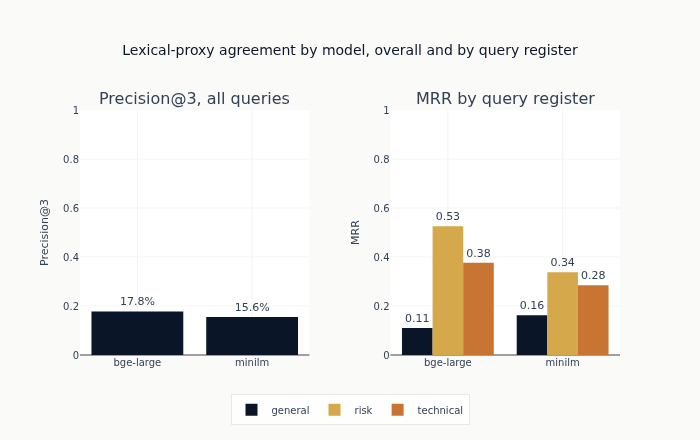

In [28]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=("Precision@3, all queries", "MRR by query register"),
    horizontal_spacing=0.15,
)
fig.add_trace(
    go.Bar(
        x=model_summary["model"].to_list(),
        y=model_summary["avg_p@3"].to_list(),
        marker_color=COLORS["blue"],
        text=[f"{v:.1%}" for v in model_summary["avg_p@3"].to_list()],
        textposition="outside",
        showlegend=False,
    ),
    row=1,
    col=1,
)

query_types = sorted(type_summary["query_type"].unique().to_list())
query_colors = dict(zip(query_types, ml4t_palette(len(query_types), categorical=True), strict=True))
for qtype in query_types:
    subset = type_summary.filter(pl.col("query_type") == qtype).sort("model")
    fig.add_trace(
        go.Bar(
            name=qtype,
            x=subset["model"].to_list(),
            y=subset["avg_mrr"].to_list(),
            text=[f"{v:.2f}" for v in subset["avg_mrr"].to_list()],
            textposition="outside",
            marker_color=query_colors[qtype],
        ),
        row=1,
        col=2,
    )

fig.update_layout(
    title="Lexical-proxy agreement by model, overall and by query register",
    height=440,
    showlegend=True,
    legend=dict(orientation="h", yanchor="top", y=-0.16, xanchor="center", x=0.5),
    margin=dict(t=110, b=85),
)
fig.update_yaxes(title_text="Precision@3", range=[0, 1], row=1, col=1)
fig.update_yaxes(title_text="MRR", range=[0, 1], row=1, col=2)
show_plotly_with_alt(
    fig,
    "Two bar panels, both on a scale running from zero to one. Left: Precision@3 for the two "
    "models, with bars around a fifth of the way up the axis and near enough the same height "
    "as each other. Right: mean reciprocal rank split into three query registers for each "
    "model. Within bge-large the risk register stands highest, technical next and general "
    "lowest by a wide margin; minilm repeats that order at lower values, except on the "
    "general register, where minilm stands slightly above bge-large.",
)

Each right-hand bar averages five queries, so the ordering within a register
rests on a handful of documents. The registers are there to show that one
aggregate can hide a reversal, not to rank the models per register.

## 7. What this evaluation can and cannot decide

### What it decides

It decides that the pipeline works: two models with different dimensions load
from pinned revisions, embed the same corpus on the same device, and produce
rankings that a metric can be computed over. That is worth having before any
model is chosen, because it is the part a reader has to rebuild for their own
corpus.

### What it does not decide

It does not decide which model to deploy. The evidence against that is in
the document counts above and in the tie column of the proxy section: the two
models are separated by a single document, and for several of the queries the
labels they are scored against were settled by a tie-break rather than by the
query.

### What would decide it

Human relevance judgments on a query set drawn from the questions analysts
actually ask, sized so that a difference between two models is more than one
document. Latency and cost measured on the same workload, because an embedding
that retrieves marginally better and costs ten times more is not better. And a
corpus cut the way production will cut it: this one is a supplier window,
and the first section says why that matters.

In [29]:
best_model = model_summary.row(0, named=True)
baseline_model = model_summary.row(-1, named=True)

print("=== Lexical-proxy agreement, this run ===\n")
for row in model_summary.iter_rows(named=True):
    print(
        f"{row['model']:<12} P@1 {row['avg_p@1']:.3f}  P@3 {row['avg_p@3']:.3f}  "
        f"P@5 {row['avg_p@5']:.3f} (ceiling 0.600)  MRR {row['avg_mrr']:.3f}"
    )

=== Lexical-proxy agreement, this run ===

bge-large    P@1 0.200  P@3 0.178  P@5 0.133 (ceiling 0.600)  MRR 0.338
minilm       P@1 0.067  P@3 0.156  P@5 0.147 (ceiling 0.600)  MRR 0.261


## Key takeaways

Every number below is read out of this run rather than written into the text.

In [30]:
slice_leaders = (
    type_summary.sort(["query_type", "avg_mrr", "model"], descending=[False, True, False])
    .group_by("query_type", maintain_order=True)
    .first()
)
leader_text = ", ".join(
    f"{row['query_type']}: {row['model']} at {row['avg_mrr']:.2f}"
    for row in slice_leaders.iter_rows(named=True)
)
worst_tie = proxy_ties.row(0, named=True)
tie_threshold = 8
arbitrary = proxy_ties.filter(pl.col("tied_but_unlabelled") >= tie_threshold).height
per_register = queries_df.group_by("query_type").len().sort("len")["len"].unique().sort().to_list()
register_count = (
    f"{per_register[0]}" if len(per_register) == 1 else f"{per_register[0]} to {per_register[-1]}"
)

display(
    Markdown(
        f"""
1. **The two models are separated by {hit_gap} document{"" if hit_gap == 1 else "s"}.**
   `{lead["model"]}` puts {lead["top3_hits"]} proxy-labelled documents into a top-3 and
   `{trail["model"]}` puts {trail["top3_hits"]}, out of {available} available. The
   Precision@3 averages for the same two models, {p3[lead["model"]]:.1%} against
   {p3[trail["model"]]:.1%}, are that fact in a form that looks larger than it is.
2. **Some of the labels are decided by a hash, not by the query.** In {arbitrary} of the
   {N_QUERIES} queries there are {tie_threshold} or more documents that score exactly as
   well as a label the rule awarded and did not get one. The worst,
   "{worst_tie["query"]}", cuts off at an overlap of {worst_tie["cutoff_overlap"]}:
   {worst_tie["tied_at_cutoff"]} documents reach it, {worst_tie["labels_from_tie"]} of the
   three labels come out of that tie, and the other {worst_tie["tied_but_unlabelled"]} score
   nothing for a retriever that returns them.
3. **Precision@5 has a lower ceiling than Precision@3.** With three labels per query it
   cannot exceed three in five, so a P@5 below a P@3 is arithmetic rather than a decline in
   retrieval.
4. **The registers do not agree on an ordering.** Highest MRR by register:
   {leader_text}. Each of those averages {register_count} queries, which is enough to show
   that one aggregate can hide a reversal and not enough to say which model owns a
   register.
5. **The run is reproducible and costs nothing.** Pinned BGE-large and MiniLM revisions, a
   hashed corpus and query set, one GPU, no managed API. That is what makes it worth
   rebuilding against labels that mean something.
"""
    )
)


1. **The two models are separated by 1 document.**
   `bge-large` puts 8 proxy-labelled documents into a top-3 and
   `minilm` puts 7, out of 45 available. The
   Precision@3 averages for the same two models, 17.8% against
   15.6%, are that fact in a form that looks larger than it is.
2. **Some of the labels are decided by a hash, not by the query.** In 7 of the
   15 queries there are 8 or more documents that score exactly as
   well as a label the rule awarded and did not get one. The worst,
   "What recent acquisitions or divestitures has the company made?", cuts off at an overlap of 1:
   41 documents reach it, 2 of the
   three labels come out of that tie, and the other 39 score
   nothing for a retriever that returns them.
3. **Precision@5 has a lower ceiling than Precision@3.** With three labels per query it
   cannot exceed three in five, so a P@5 below a P@3 is arithmetic rather than a decline in
   retrieval.
4. **The registers do not agree on an ordering.** Highest MRR by register:
   general: minilm at 0.16, risk: bge-large at 0.53, technical: bge-large at 0.38. Each of those averages 5 queries, which is enough to show
   that one aggregate can hide a reversal and not enough to say which model owns a
   register.
5. **The run is reproducible and costs nothing.** Pinned BGE-large and MiniLM revisions, a
   hashed corpus and query set, one GPU, no managed API. That is what makes it worth
   rebuilding against labels that mean something.


In [31]:
completion_record = {
    "input_sha256": INPUT_SHA256,
    "selected_corpus_sha256": CORPUS_SHA256,
    "query_sha256": QUERY_SHA256,
    "documents": len(FINANCIAL_DOCUMENTS),
    "queries": len(FINANCIAL_QUERIES),
    "models": sorted(document_embeddings),
    "model_revisions": MODEL_REVISIONS,
    "device": EMBEDDING_DEVICE,
    "results": model_summary.to_dicts(),
}
print(f"COMPLETION_RECORD={json.dumps(completion_record, sort_keys=True)}")

COMPLETION_RECORD={"device": "cuda", "documents": 191, "input_sha256": "d0d8021167f79c49e0a5a4420294c9ff2f3534e4c9eb10f580c3e3901fb4945b", "model_revisions": {"BAAI/bge-large-en-v1.5": "d4aa6901d3a41ba39fb536a557fa166f842b0e09", "sentence-transformers/all-MiniLM-L6-v2": "1110a243fdf4706b3f48f1d95db1a4f5529b4d41"}, "models": ["bge-large", "minilm"], "queries": 15, "query_sha256": "01f14c7320311b0cd03ba5d48de46cdec20b4c4c2eca6d00a932bbb3a8f627f2", "results": [{"avg_mrr": 0.3377323826899378, "avg_p@1": 0.2, "avg_p@3": 0.17777777777777776, "avg_p@5": 0.13333333333333333, "model": "bge-large"}, {"avg_mrr": 0.2614417989417989, "avg_p@1": 0.06666666666666667, "avg_p@3": 0.15555555555555553, "avg_p@5": 0.14666666666666667, "model": "minilm"}], "selected_corpus_sha256": "242a2e1009e1c6350700290e3acc7ffb365e34820ded19453348bfd1b164866c"}


**Next**: [`03_hybrid_retrieval`](03_hybrid_retrieval.ipynb) combines these
embeddings with BM25 keyword search through reciprocal rank fusion, and scores
the combined ranking against the same kind of proxy.